In [2]:
import tensorflow as tf
from tensorflow import keras

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1452s 9us/step


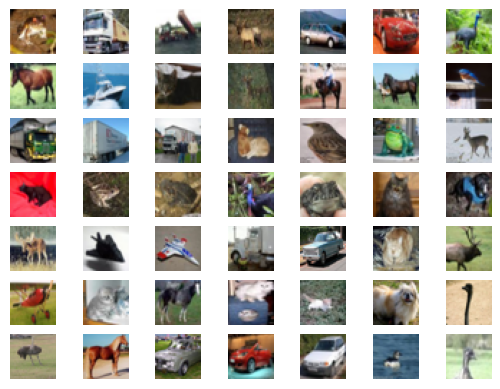

In [3]:
from tensorflow.keras.datasets.cifar10 import load_data
import matplotlib.pyplot as plt

(trainX,trainy), (testX,testy) = load_data()

for i in range(49):
  plt.subplot(7,7,1+i)

  plt.axis('off')
  plt.imshow(trainX[i])

plt.show()

In [4]:
print(trainX.shape)
print(testX.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [29]:
np.unique(trainy)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [5]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, Flatten, Dropout, LeakyReLU
from tensorflow.keras.utils import plot_model
import numpy as np

In [30]:
# define the standalone discriminator model
def define_discriminator(in_shape=(32,32,3)):
  model = Sequential()
  #normal
  model.add(Conv2D(64, (3,3), padding='same', input_shape=in_shape))
  model.add(LeakyReLU(alpha= 0.2))
  #downsample
  model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha= 0.2))
  #downsample
  model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha= 0.2))
  #downsample
  model.add(Conv2D(256, (3,3), strides=(2,2), padding='same'))
  model.add(LeakyReLU(alpha= 0.2))
  #classifier
  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1,activation = 'sigmoid'))
  #compile model
  opt = Adam(learning_rate = 0.0002, beta_1= 0.5)
  model.compile(loss = 'binary_crossentropy', optimizer = opt, metrics = ['accuracy'])

  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

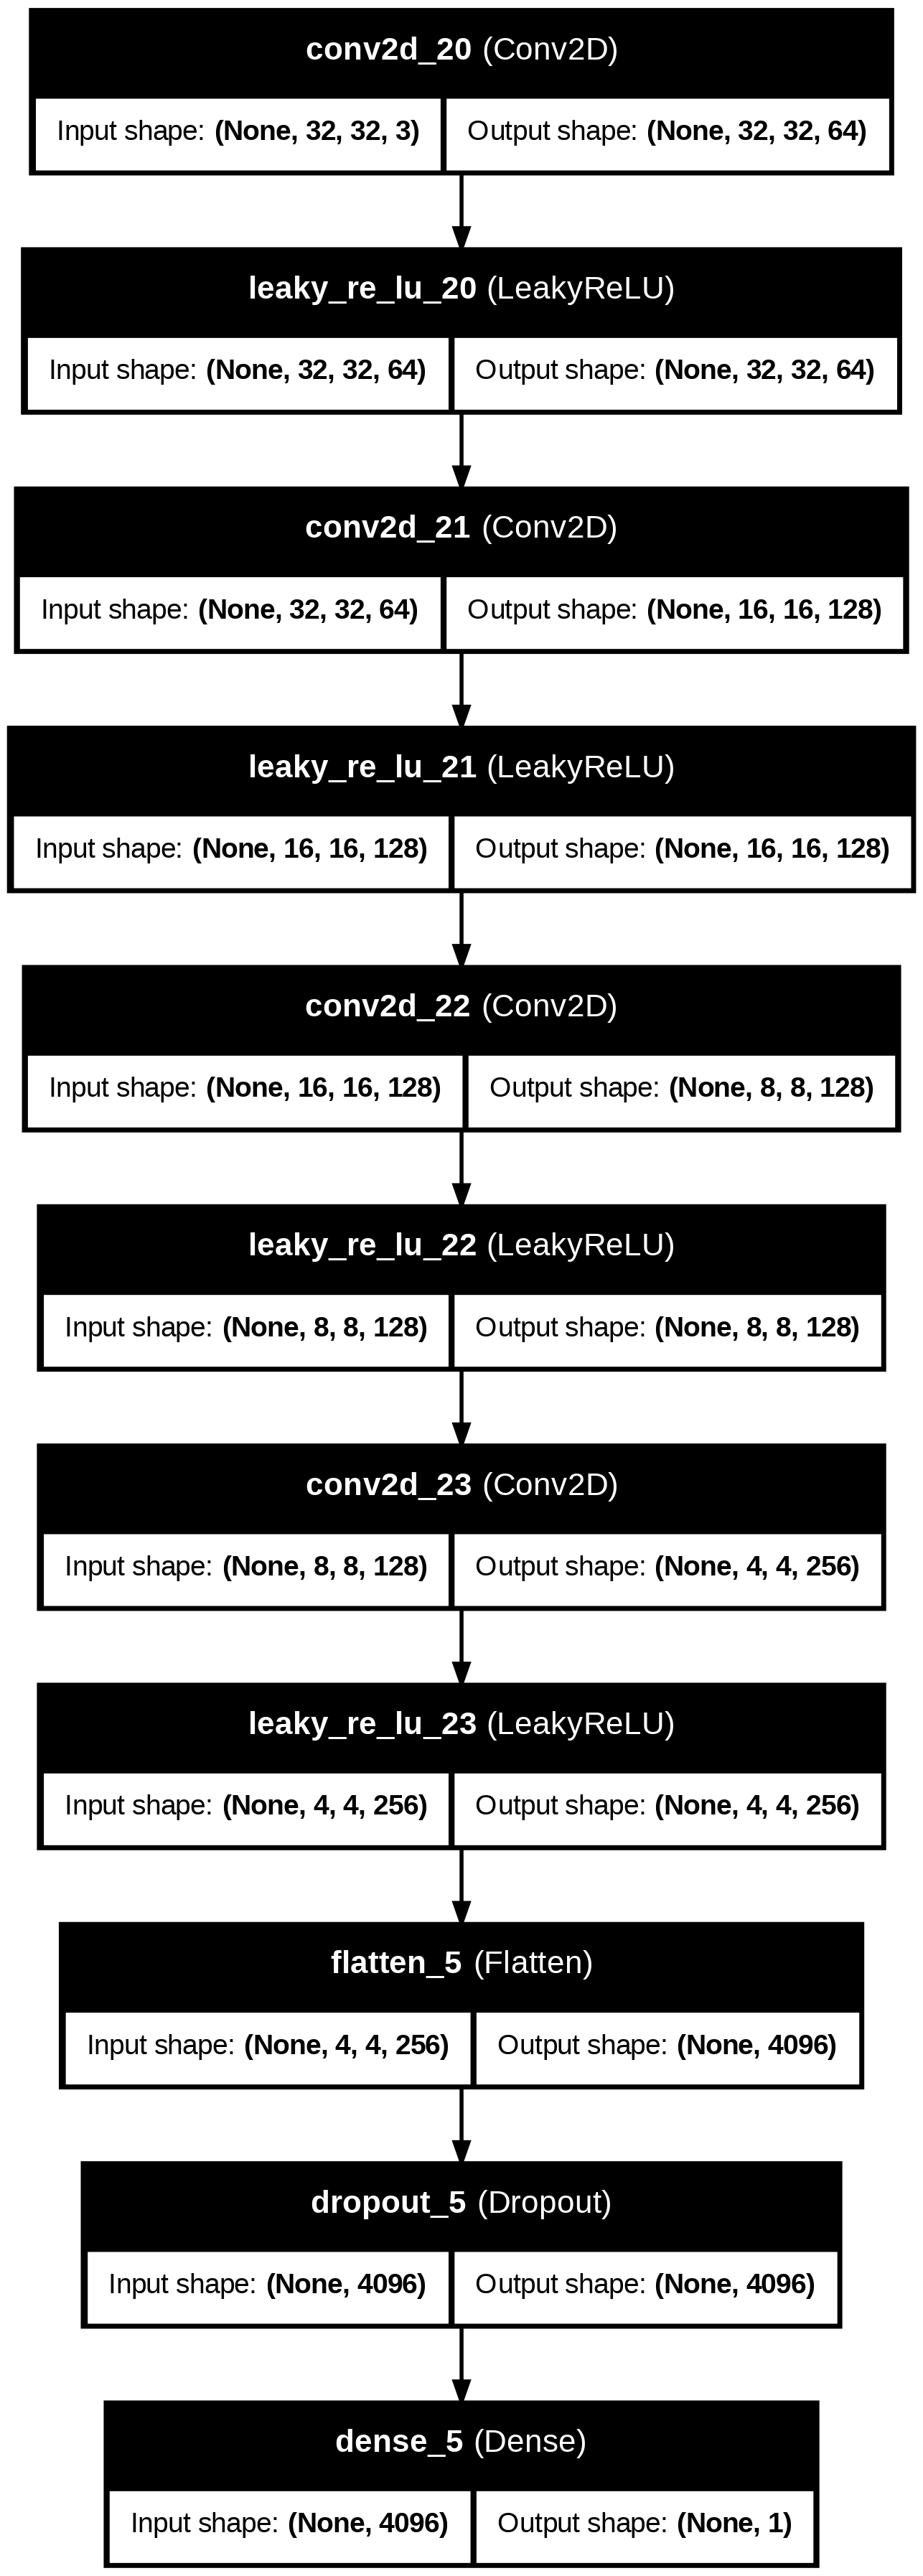

In [31]:
#define model
model = define_discriminator()
model.summary()
plot_model(model, to_file = 'discriminator_plot.png', show_shapes = True, show_layer_names = True)

In [9]:
# Function to load
# load and prepare cifar10 training samples
def load_real_samples():
  # load cifar10 dataset
  (trainX, _), (_, _) = load_data()
  # convert from unsigned ints to floats
  X = trainX.astype('float32')
  # scale from [0,255] to [-1,1]
  X = (X - 127.5) / 127.5
  return X

In [56]:
X = load_real_samples()
X[0]

array([[[-0.5372549 , -0.5137255 , -0.5058824 ],
        [-0.6627451 , -0.6392157 , -0.64705884],
        [-0.60784316, -0.62352943, -0.6627451 ],
        ...,
        [ 0.23921569,  0.03529412, -0.15294118],
        [ 0.19215687, -0.01960784, -0.2       ],
        [ 0.16078432, -0.02745098, -0.19215687]],

       [[-0.8745098 , -0.84313726, -0.84313726],
        [-1.        , -1.        , -1.        ],
        [-0.85882354, -0.9372549 , -1.        ],
        ...,
        [-0.03529412, -0.30980393, -0.5686275 ],
        [-0.06666667, -0.34901962, -0.60784316],
        [-0.04313726, -0.31764707, -0.5529412 ]],

       [[-0.8039216 , -0.8117647 , -0.8352941 ],
        [-0.8745098 , -0.94509804, -1.        ],
        [-0.6156863 , -0.7882353 , -0.9372549 ],
        ...,
        [-0.07450981, -0.34117648, -0.60784316],
        [-0.05882353, -0.34117648, -0.60784316],
        [-0.14509805, -0.42745098, -0.67058825]],

       ...,

       [[ 0.6313726 ,  0.33333334, -0.24705882],
        [ 0

In [57]:
def generate_real_samples(dataset, n_samples):
  # choose random instances
  ix = np.random.randint(0, dataset.shape[0], n_samples)
  # retrieve selected images
  X = dataset[ix]
  # generate 'real' class labels (1)
  y = np.ones((n_samples, 1))
  return X, y

In [59]:
X1,y1 = generate_real_samples(X,64)
print(X1.shape)
print(y1.shape)
print(y1)

(64, 32, 32, 3)
(64, 1)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


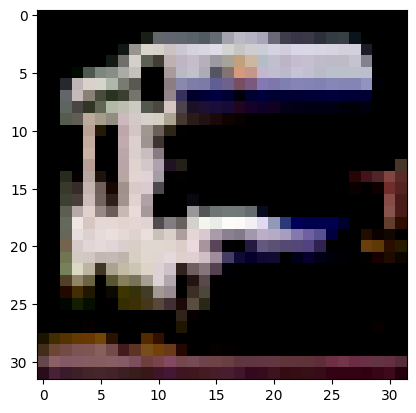

In [61]:
plt.imshow(X1[5])

In [62]:
def generate_fake_samples(n_samples):
  X = np.random.uniform(-1,1,(n_samples,32,32,3))
  y = np.zeros((n_samples,1))
  return X,y

In [63]:
X,y = generate_fake_samples(64)
print(X.shape)
print(y.shape)
print(y)

(64, 32, 32, 3)
(64, 1)
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


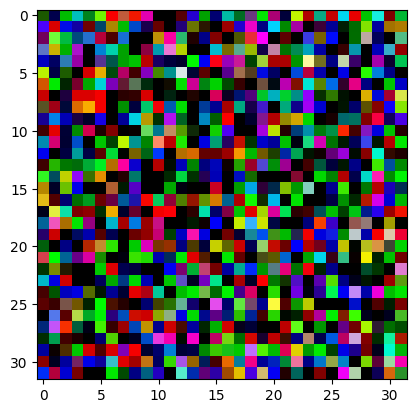

In [64]:
plt.imshow(X[0])

In [68]:
def train_discriminator(model, dataset, n_iter = 100, n_batch = 128):
  half_batch = int(n_batch / 2)
  for i in range(n_iter):
    X_real, y_real = generate_real_samples(dataset, half_batch)
    _, real_acc = model.train_on_batch(X_real, y_real)

    X_fake, y_fake = generate_fake_samples(half_batch)
    _, fake_acc = model.train_on_batch(X_fake, y_fake)

    print('>%d real=%.0f%% fake=%.0f%%' % (i+1, real_acc*100, fake_acc*100))

In [69]:
model = define_discriminator()
dataset = load_real_samples()
train_discriminator(model, dataset)

>1 real=36% fake=18%
>2 real=44% fake=34%
>3 real=47% fake=41%
>4 real=49% fake=48%
>5 real=53% fake=56%
>6 real=59% fake=62%
>7 real=65% fake=67%
>8 real=69% fake=71%
>9 real=72% fake=74%
>10 real=75% fake=76%
>11 real=77% fake=78%
>12 real=79% fake=80%
>13 real=80% fake=81%
>14 real=82% fake=82%
>15 real=83% fake=84%
>16 real=84% fake=85%
>17 real=85% fake=85%
>18 real=86% fake=86%
>19 real=87% fake=87%
>20 real=87% fake=88%
>21 real=88% fake=88%
>22 real=88% fake=89%
>23 real=89% fake=89%
>24 real=89% fake=90%
>25 real=90% fake=90%
>26 real=90% fake=90%
>27 real=91% fake=91%
>28 real=91% fake=91%
>29 real=91% fake=91%
>30 real=92% fake=92%
>31 real=92% fake=92%
>32 real=92% fake=92%
>33 real=92% fake=92%
>34 real=93% fake=93%
>35 real=93% fake=93%
>36 real=93% fake=93%
>37 real=93% fake=93%
>38 real=93% fake=93%
>39 real=94% fake=94%
>40 real=94% fake=94%
>41 real=94% fake=94%
>42 real=94% fake=94%
>43 real=94% fake=94%
>44 real=94% fake=94%
>45 real=94% fake=94%
>46 real=95% fake=9

In [72]:
from keras.models import Sequential
from keras.layers import Dense, Reshape, Conv2D, Conv2DTranspose, LeakyReLU
from tensorflow.keras.utils import plot_model

In [75]:
def define_generator(latent_dim):
  model = Sequential()
  #foundation for 4*4 image
  n_nodes = 256 * 4 * 4
  model.add(Dense(n_nodes, input_dim = latent_dim))
  model.add(LeakyReLU(alpha = 0.2))
  model.add(Reshape((4,4,256)))
  #upsample to 8*8
  model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = 'same'))
  model.add(LeakyReLU(alpha = 0.2))
  #upsample to 16*18
  model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = 'same'))
  model.add(LeakyReLU(alpha = 0.2))
  #upsample to 32*32
  model.add(Conv2DTranspose(128, (4,4), strides = (2,2), padding = 'same'))
  model.add(LeakyReLU(alpha = 0.2))

  model.add(Conv2D(3, (3,3), activation = 'tanh', padding = 'same'))

  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_32 (LeakyReLU)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_33 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_34 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_35 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

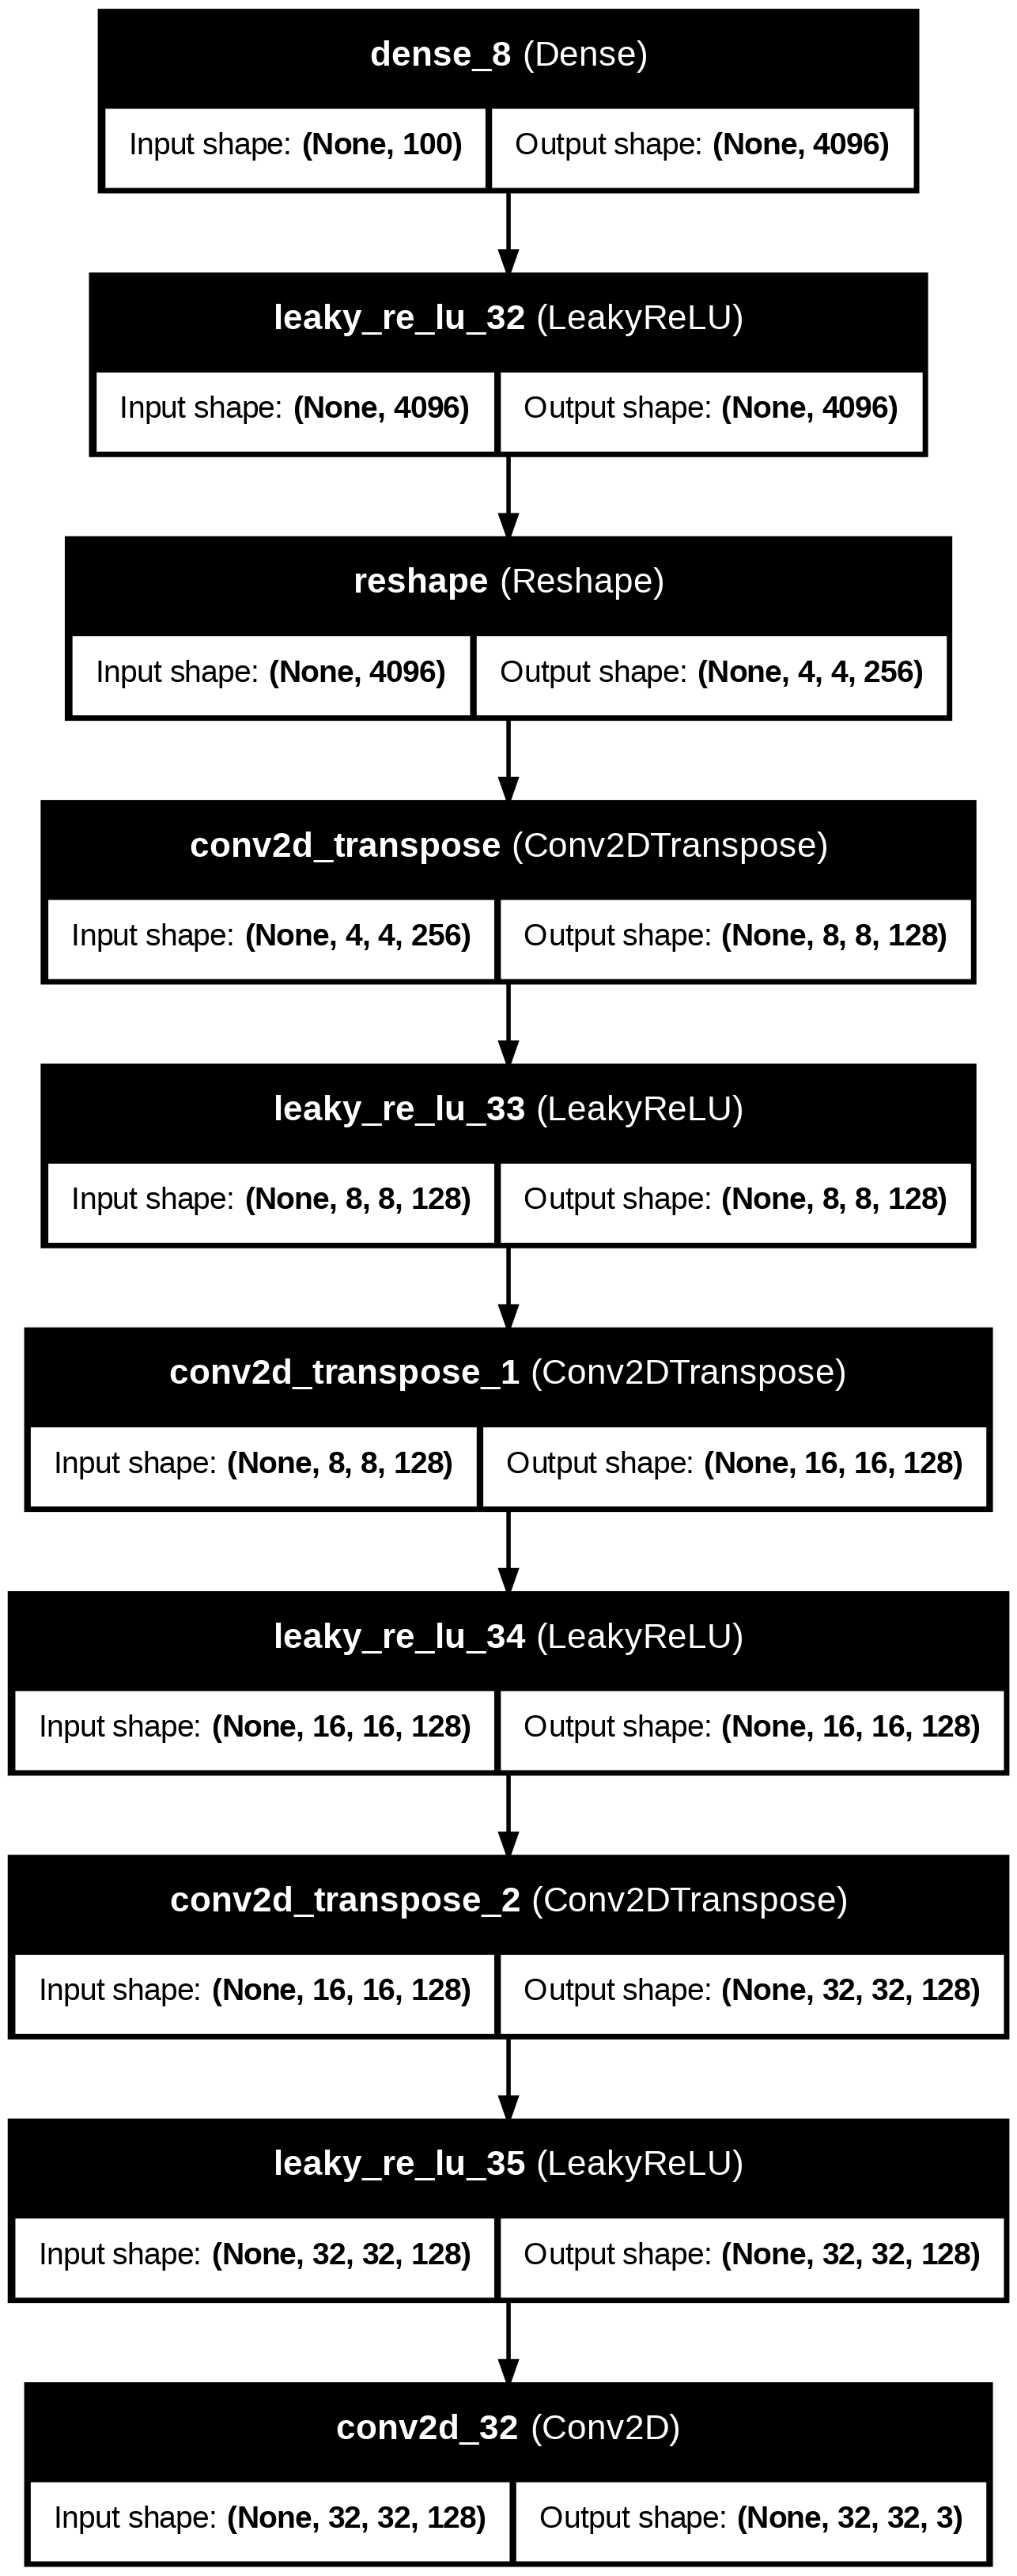

In [76]:
#define the size of latent space
latent_dim = 100
model = define_generator(latent_dim)
model.summary()
plot_model(model, to_file = 'generator_plot.png', show_shapes = True, show_layer_names = True)

In [77]:
def generate_latent_points(latent_dim, n_samples):
  x_input = np.random.randn(latent_dim * n_samples)
  x_input = x_input.reshape(n_samples, latent_dim)
  return x_input

In [80]:
x_input = generate_latent_points(100,64)
x_input.shape

(64, 100)

In [78]:
def generate_fake_samples(g_model, latent_dim, n_samples):
  x_input = generate_latent_points(latent_dim, n_samples)

  x = g_model.predict(x_input)

  y = np.zeros((n_samples,1))

  return x,y

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


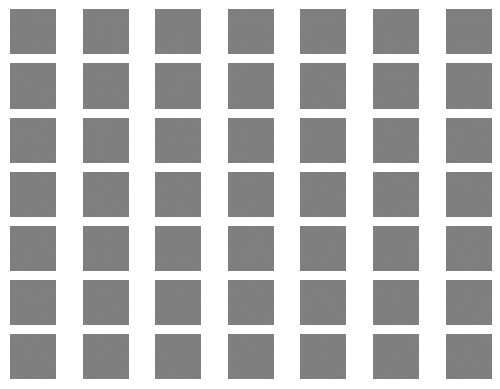

In [81]:
latent_dim = 100
model = define_generator(latent_dim)
n_samples = 49
X,_ = generate_fake_samples(model, latent_dim, 64)

X= (X + 1) / 2.0

for i in range(n_samples):
  plt.subplot(7,7,1+i)
  plt.axis('off')
  plt.imshow(X[i])

plt.show()

In [82]:
def define_gan(g_model, d_model):
  d_model.trainable = False
  model = Sequential()
  model.add(g_model)
  model.add(d_model)

  opt = Adam(learning_rate = 0.0002, beta_1 = 0.5)
  model.compile(loss = 'binary_crossentropy', optimizer = opt)

  return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_10 (Sequential)      │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

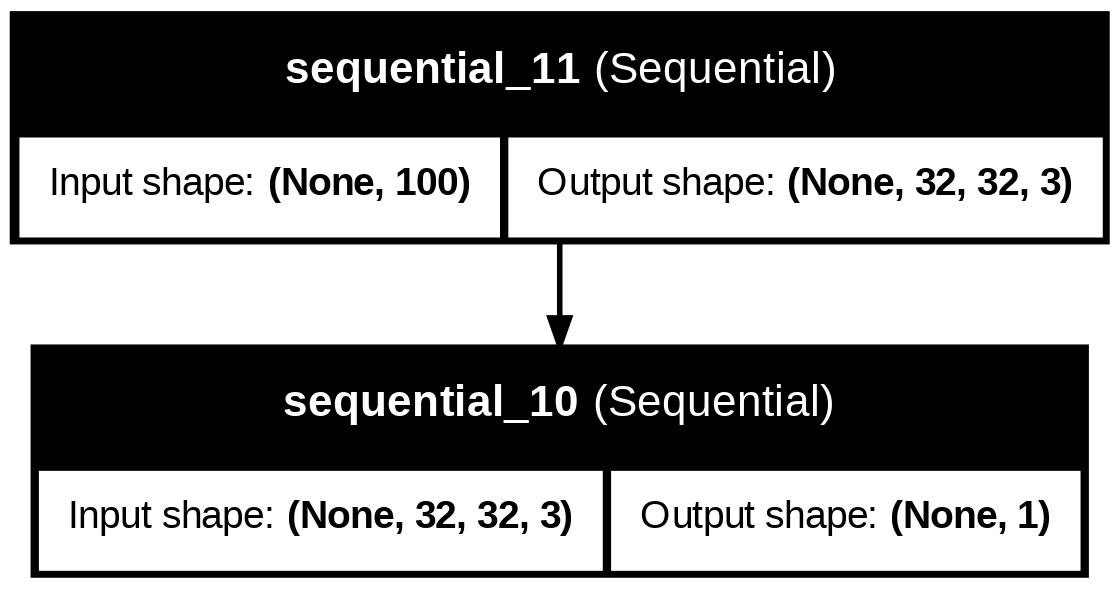

In [83]:
latent_dim = 100
d_model = define_discriminator()
g_model = define_generator(latent_dim)
gan_model = define_gan(g_model, d_model)

gan_model.summary()
plot_model(gan_model, to_file = 'gan_plot.png', show_shapes = True, show_layer_names = True)

In [87]:
def train(g_model, d_model, gan_model, dataset, latent_dim,n_epochs = 200, n_batch = 128):

  bat_per_epo = int(dataset.shape[0] / n_batch)
  half_batch = int(n_batch / 2)

  for i in range(n_epochs):
    for j in range(bat_per_epo):
      X_real, y_real = generate_real_samples(dataset, half_batch)
      X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

      d_loss1,_ =d_model.train_on_batch(X_real, y_real)
      d_loss2, _ =d_model.train_on_batch(X_fake, y_fake)

      X_gan = generate_latent_points(latent_dim, n_batch)
      y_gan = np.ones((n_batch,1))

      g_loss = gan_model.train_on_batch(X_gan, y_gan)

      print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' % (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))

    if (i+1) % 10 == 0:
      summarize_performance(i, g_model, d_model, dataset, latent_dim)

In [86]:
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples = 150):

  X_real, y_real = generate_real_samples(dataset, n_samples)
  _, acc_real = d_model.evaluate(X_real, y_real, verbose = 0)

  x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
  _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose = 0)

  print('Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))

  save_plot(x_fake,epoch)
  filename = 'generator_model_%03d.h5' % (epoch + 1)
  g_model.save(filename)

In [85]:
def save_plot(examples, epoch, n = 7):

  examples = (examples +1)/2.0

  for i in range(n*n):
    plt.subplot(n,n,1+i)
    plt.axis('off')
    plt.imshow(examples[i])

  filename = 'generated_plot_e%03d.png' % (epoch+1)
  plt.savefig(filename)
  plt.close

In [88]:
train(g_model, d_model, gan_model, dataset, latent_dim,n_epochs = 200, n_batch = 128)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


>1, 1/390, d1=0.710, d2=0.702 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
>1, 2/390, d1=0.703, d2=0.701 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 355ms/step
>1, 3/390, d1=0.701, d2=0.700 g=0.693
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
>1, 4/390, d1=0.701, d2=0.700 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
>1, 5/390, d1=0.701, d2=0.700 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
>1, 6/390, d1=0.701, d2=0.700 g=0.691
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
>1, 7/390, d1=0.701, d2=0.701 g=0.690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
>1, 8/390, d1=0.701, d2=0.702 g=0.689
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
>1, 9/390, d1=0.702, d2=0.703 g=0.687
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
>1, 10/390, d1=0.703, d2=0.704 g=0.685
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
>1, 11/390, d1=0.704, d2=0.705 g=0.682
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
>1, 12/390, d1=0.705, d2=0.707 g=0.679
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 359ms/step
>1, 13/390, d1=0.707, d2=0.710 g=0.674
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/

KeyboardInterrupt: 